Imoporting all relevant packages

In [40]:
import pandas as pd
import numpy as ny
import matplotlib.pyplot as plt
import statsmodels.graphics.tsaplots as sgt
import statsmodels.tsa.stattools as sts
import seaborn as sns
sns.set()

Loading and transforming the data to required form(date as index)

In [41]:
##importing data
raw_data = pd.read_csv("./datasets/index2018.csv")
comp_df = raw_data.copy()
##correcting date format
comp_df.date = pd.to_datetime(comp_df.date, dayfirst=True)
##setting date as index
comp_df.set_index("date", inplace=True)
##setting frequency(Business days)
comp_df=comp_df.asfreq("B")
##Filling missing values
comp_df=comp_df.fillna(method="ffill")

C:\Users\USER\AppData\Local\Temp\ipykernel_13304\1910940189.py:11: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  comp_df=comp_df.fillna(method="ffill")


Removing surplus from data and splitting it

In [42]:
##creating new column
comp_df["market_price"] = comp_df.ftse
##deleting other redundant columns
del comp_df["spx"]
del comp_df["dax"]
del comp_df["ftse"]
del comp_df["nikkei"]
##splitting data
size = int(len(comp_df) * 0.8)
df,df_test = comp_df.iloc[:size], comp_df.iloc[size:]

Auto-Correlation Function (ACF)

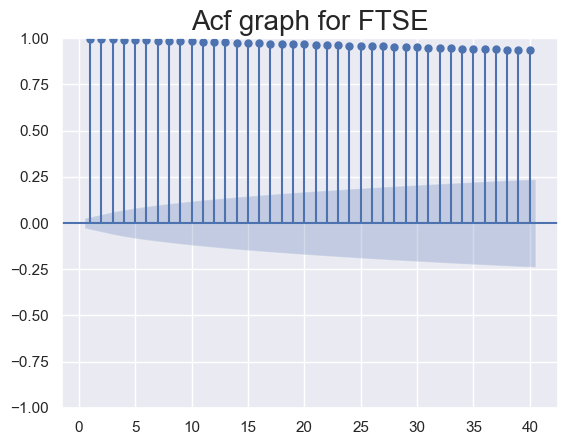

In [43]:
sgt.plot_acf(df.market_price, lags = 40, zero = False)
plt.title("Acf graph for FTSE", size=20)
plt.show()

Partial Auto-correlation (PACF)

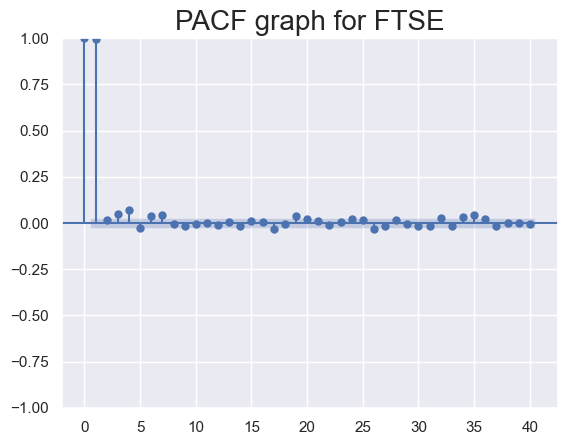

In [44]:
sgt.plot_pacf(df.market_price, lags=40, method="ols",)
plt.title("PACF graph for FTSE", size=20)
plt.show()

The AR[1] model

In [45]:
from statsmodels.tsa.arima.model import ARIMA

In [46]:
def model(x):
    return ARIMA(df["market_price"],order=(x,0,0))

model_ar = model(1)

In [47]:
result_ar = model_ar.fit()

In [48]:
result_ar.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:           market_price   No. Observations:                 5021
Model:                 ARIMA(1, 0, 0)   Log Likelihood              -27622.604
Date:                Sat, 02 Aug 2025   AIC                          55251.207
Time:                        11:21:16   BIC                          55270.772
Sample:                    01-07-1994   HQIC                         55258.063
                         - 04-05-2013                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       5089.6374    423.329     12.023      0.000    4259.929    5919.346
ar.L1          0.9984      0.001   1147.578      0.000       0.997       1.000
sigma2      3511.3842     40.874     85.907      0.000    3431.272    3591.496
===================================================================================
Ljung-Box (L1) (Q):                   1.51   Jarque-Bera (JB):              3313.33
Prob(Q):                              0.22   Prob(JB):                         0.00
Heteroskedasticity (H):               1.90   Skew:                            -0.18
Prob(H) (two-sided):                  0.00   Kurtosis:                         6.96
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Higher Lag AR models

In [49]:
model_ar_2 = model(2) 
model_ar_3 = model(3) 
model_ar_4 = model(4)

result_ar_2 = model_ar_2.fit()
result_ar_3 = model_ar_3.fit()
result_ar_4 = model_ar_4.fit()

In [50]:
result_ar_2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:           market_price   No. Observations:                 5021
Model:                 ARIMA(2, 0, 0)   Log Likelihood              -27621.949
Date:                Sat, 02 Aug 2025   AIC                          55251.898
Time:                        11:21:19   BIC                          55277.984
Sample:                    01-07-1994   HQIC                         55261.039
                         - 04-05-2013                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       5089.6409    368.251     13.821      0.000    4367.881    5811.400
ar.L1          0.9811      0.010     99.868      0.000       0.962       1.000
ar.L2          0.0171      0.010      1.749      0.080      -0.002       0.036
sigma2      3510.1277     41.037     85.535      0.000    3429.696    3590.560
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):              3282.81
Prob(Q):                              0.95   Prob(JB):                         0.00
Heteroskedasticity (H):               1.89   Skew:                            -0.19
Prob(H) (two-sided):                  0.00   Kurtosis:                         6.94
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [51]:
result_ar_3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:           market_price   No. Observations:                 5021
Model:                 ARIMA(3, 0, 0)   Log Likelihood              -27615.962
Date:                Sat, 02 Aug 2025   AIC                          55241.925
Time:                        11:21:19   BIC                          55274.532
Sample:                    01-07-1994   HQIC                         55253.351
                         - 04-05-2013                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       5089.6409    378.583     13.444      0.000    4347.631    5831.651
ar.L1          0.9802      0.010     99.076      0.000       0.961       1.000
ar.L2         -0.0309      0.013     -2.315      0.021      -0.057      -0.005
ar.L3          0.0489      0.009      5.383      0.000       0.031       0.067
sigma2      3502.2643     41.020     85.379      0.000    3421.866    3582.662
===================================================================================
Ljung-Box (L1) (Q):                   0.06   Jarque-Bera (JB):              3286.97
Prob(Q):                              0.80   Prob(JB):                         0.00
Heteroskedasticity (H):               1.90   Skew:                            -0.22
Prob(H) (two-sided):                  0.00   Kurtosis:                         6.94
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [52]:
result_ar_4.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:           market_price   No. Observations:                 5021
Model:                 ARIMA(4, 0, 0)   Log Likelihood              -27602.680
Date:                Sat, 02 Aug 2025   AIC                          55217.359
Time:                        11:21:19   BIC                          55256.488
Sample:                    01-07-1994   HQIC                         55231.070
                         - 04-05-2013                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       5089.6409    391.959     12.985      0.000    4321.416    5857.866
ar.L1          0.9767      0.010     97.788      0.000       0.957       0.996
ar.L2         -0.0287      0.013     -2.129      0.033      -0.055      -0.002
ar.L3         -0.0224      0.013     -1.784      0.074      -0.047       0.002
ar.L4          0.0728      0.009      8.033      0.000       0.055       0.091
sigma2      3484.0262     41.922     83.108      0.000    3401.861    3566.191
===================================================================================
Ljung-Box (L1) (Q):                   0.02   Jarque-Bera (JB):              3044.18
Prob(Q):                              0.88   Prob(JB):                         0.00
Heteroskedasticity (H):               1.90   Skew:                            -0.28
Prob(H) (two-sided):                  0.00   Kurtosis:                         6.77
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Log-Likelihood-Ratio (LLR) Test

In [53]:
from scipy.stats.distributions import chi2

In [54]:
def LLR_test(mod_1, mod_2, DF=1):
    l1 = mod_1.fit().llf
    l2 = mod_2.fit().llf
    LR = 2*(l2-l1)
    p = chi2.sf(LR,DF).round(3)
    return p

Comparing Models

In [55]:
LLR_test(model_ar_2,model_ar_3)

np.float64(0.001)

In [56]:
LLR_test(model_ar,model_ar_2)

np.float64(0.253)

In [57]:
LLR_test(model_ar_3,model_ar_4)

np.float64(0.0)

Test to pick the best model

In [58]:


model_ar_5 = model(5)
model_ar_6 = model(6)
model_ar_7 = model(7)
model_ar_8 = model(8)
model_ar_9 = model(9)

result_ar_5 = model_ar_5.fit()
result_ar_6 = model_ar_6.fit()
result_ar_7 = model_ar_7.fit()
result_ar_8 = model_ar_8.fit()
result_ar_9 = model_ar_9.fit()

In [59]:
print(result_ar_5.summary())
print("LLR=" + str(LLR_test(model_ar_4,model_ar_5)))

                               SARIMAX Results                                
Dep. Variable:           market_price   No. Observations:                 5021
Model:                 ARIMA(5, 0, 0)   Log Likelihood              -27600.460
Date:                Sat, 02 Aug 2025   AIC                          55214.920
Time:                        11:21:37   BIC                          55260.570
Sample:                    01-07-1994   HQIC                         55230.916
                         - 04-05-2013                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       5089.6409    386.229     13.178      0.000    4332.646    5846.635
ar.L1          0.9788      0.010     97.867      0.000       0.959       0.998
ar.L2         -0.0293      0.013     -2.176      0.0

In [60]:
print(result_ar_6.summary())
print("LLR=" + str(LLR_test(model_ar_5,model_ar_6)))

                               SARIMAX Results                                
Dep. Variable:           market_price   No. Observations:                 5021
Model:                 ARIMA(6, 0, 0)   Log Likelihood              -27596.587
Date:                Sat, 02 Aug 2025   AIC                          55209.174
Time:                        11:21:40   BIC                          55261.345
Sample:                    01-07-1994   HQIC                         55227.455
                         - 04-05-2013                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       5089.6409    396.932     12.822      0.000    4311.669    5867.612
ar.L1          0.9800      0.010     96.873      0.000       0.960       1.000
ar.L2         -0.0333      0.014     -2.438      0.0

In [61]:
print(result_ar_7.summary())
print("LLR=" + str(LLR_test(model_ar_6,model_ar_7)))

                               SARIMAX Results                                
Dep. Variable:           market_price   No. Observations:                 5021
Model:                 ARIMA(7, 0, 0)   Log Likelihood              -27592.022
Date:                Sat, 02 Aug 2025   AIC                          55202.044
Time:                        11:21:43   BIC                          55260.736
Sample:                    01-07-1994   HQIC                         55222.610
                         - 04-05-2013                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       5089.6409    405.380     12.555      0.000    4295.111    5884.171
ar.L1          0.9783      0.010     95.742      0.000       0.958       0.998
ar.L2         -0.0304      0.014     -2.183      0.0

In [62]:
print(result_ar_8.summary())
print("LLR=" + str(LLR_test(model_ar_7,model_ar_8)))

                               SARIMAX Results                                
Dep. Variable:           market_price   No. Observations:                 5021
Model:                 ARIMA(8, 0, 0)   Log Likelihood              -27591.854
Date:                Sat, 02 Aug 2025   AIC                          55203.708
Time:                        11:21:47   BIC                          55268.922
Sample:                    01-07-1994   HQIC                         55226.560
                         - 04-05-2013                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       5089.6409    407.243     12.498      0.000    4291.458    5887.823
ar.L1          0.9787      0.010     95.719      0.000       0.959       0.999
ar.L2         -0.0305      0.014     -2.183      0.0

In [63]:
print(result_ar_9.summary())
print("LLR=" + str(LLR_test(model_ar_8,model_ar_9)))

                               SARIMAX Results                                
Dep. Variable:           market_price   No. Observations:                 5021
Model:                 ARIMA(9, 0, 0)   Log Likelihood              -27591.280
Date:                Sat, 02 Aug 2025   AIC                          55204.561
Time:                        11:21:52   BIC                          55276.296
Sample:                    01-07-1994   HQIC                         55229.698
                         - 04-05-2013                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       5089.6409    408.611     12.456      0.000    4288.778    5890.504
ar.L1          0.9785      0.010     95.130      0.000       0.958       0.999
ar.L2         -0.0296      0.014     -2.115      0.0

In [64]:
##CONCLUSION
##by comparing the llr test value with the p-values from the summary, we can conclude the
## model got better at predicting the higher the order until the 8th iteration
## from which the llr test p-value started increasing above the tolerance level thereby accepting the null-hypothesis
##in conclusion, ARIMA(7) model should be used

Returns

In [72]:
df["returns"] = df.market_price.pct_change(1).mul(100)

In [73]:
df = df.iloc[1:]

In [74]:
sts.adfuller(df.returns)

(np.float64(-12.773690540587952),
 np.float64(7.674029903408262e-24),
 32,
 4984,
 {'1%': np.float64(-3.4316627349870146),
  '5%': np.float64(-2.8621200865028813),
  '10%': np.float64(-2.5670787808193283)},
 np.float64(15685.390582422942))

ACF and PACF for returns

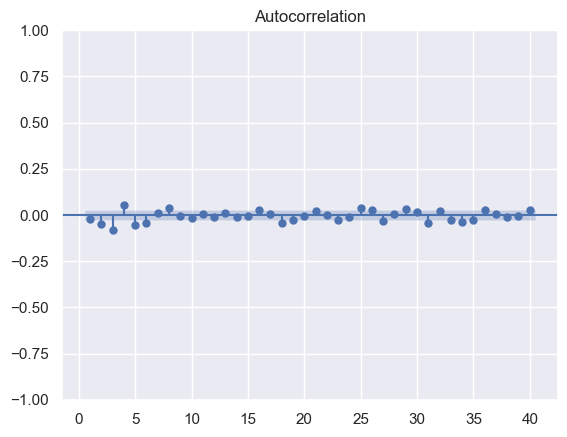

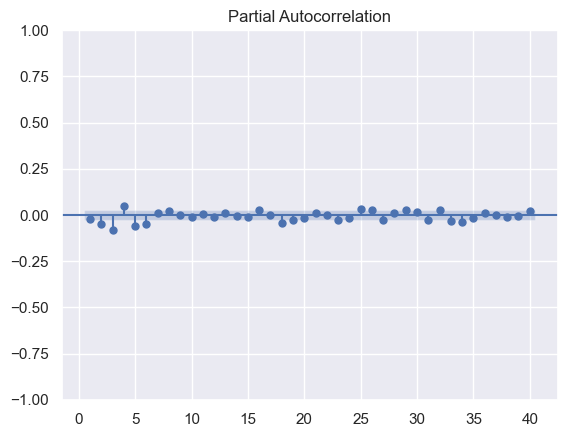

In [79]:
sgt.plot_acf(df.returns, lags = 40, zero = False)
sgt.plot_pacf(df.returns, lags = 40, zero = False, method=('ols'))
plt.show()